# **AML LAB**

## **Experiment 6**

## Credit Risk Assessment: Build a credit scoring model to assess the creditworthiness of applicants using historical financial data and perform comparative analysis (Logistic Regression, Random Forest, XGBoost)


###1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

###2. Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_7/credit_risk_assessment_500_samples.csv")

df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


###3. Data Understanding

In [ ]:
df.info()
df.isnull().sum()

# Check class distribution
df['Credit_Risk'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             500 non-null    int64  
 1   Age                      500 non-null    int64  
 2   Annual_Income            500 non-null    int64  
 3   Employment_Years         500 non-null    int64  
 4   Credit_Score             500 non-null    int64  
 5   Loan_Amount              500 non-null    int64  
 6   Loan_Term_Months         500 non-null    int64  
 7   Existing_Loans_Count     500 non-null    int64  
 8   Debt_to_Income_Ratio     500 non-null    float64
 9   Late_Payments_Last_2Yrs  500 non-null    int64  
 10  Credit_Risk              500 non-null    object 
dtypes: float64(1), int64(9), object(1)
memory usage: 43.1+ KB


,count
Credit_Risk,
High,315
Medium,164
Low,21


###4. Handle Missing Values

In [ ]:
df = df.dropna()

###5. Encode Categorical Variables

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,0
1,2,49,232745,0,436,175354,60,0,0.23,5,0
2,3,35,974945,19,797,662297,48,3,0.54,0,2
3,4,63,307164,29,776,831725,48,0,0.56,4,0
4,5,28,685626,6,893,498625,60,3,0.66,8,0


###6. Feature-Target Split

In [ ]:
X = df.drop("Credit_Risk", axis=1)
y = df["Credit_Risk"]

###7. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###8. Initialize Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

###9. Train, Predict, Evaluate

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = model.decision_function(X_test)

    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

    results[name] = [accuracy, precision, recall, f1, roc_auc]

    print("\nModel:", name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.74
Precision: 0.7070738916256157
Recall: 0.74
F1-Score: 0.7157670454545455
ROC-AUC: 0.8377368421052631
Confusion Matrix:
 [[53  1  4]
 [ 1  0  4]
 [16  0 21]]

Model: Random Forest
Accuracy: 0.98
Precision: 0.981025641025641
Recall: 0.98
F1-Score: 0.9777631578947369
ROC-AUC: 0.9996825396825397
Confusion Matrix:
 [[58  0  0]
 [ 0  3  2]
 [ 0  0 37]]

Model: XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0
Confusion Matrix:
 [[58  0  0]
 [ 0  5  0]
 [ 0  0 37]]


###10. Comparative Performance Table

In [ ]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

results_df

,Logistic Regression,Random Forest,XGBoost
Accuracy,0.740000,0.980000,1.0
Precision,0.707074,0.981026,1.0
Recall,0.740000,0.980000,1.0
F1-Score,0.715767,0.977763,1.0
ROC-AUC,0.837737,0.999683,1.0


###11. Visualization: Model Comparison

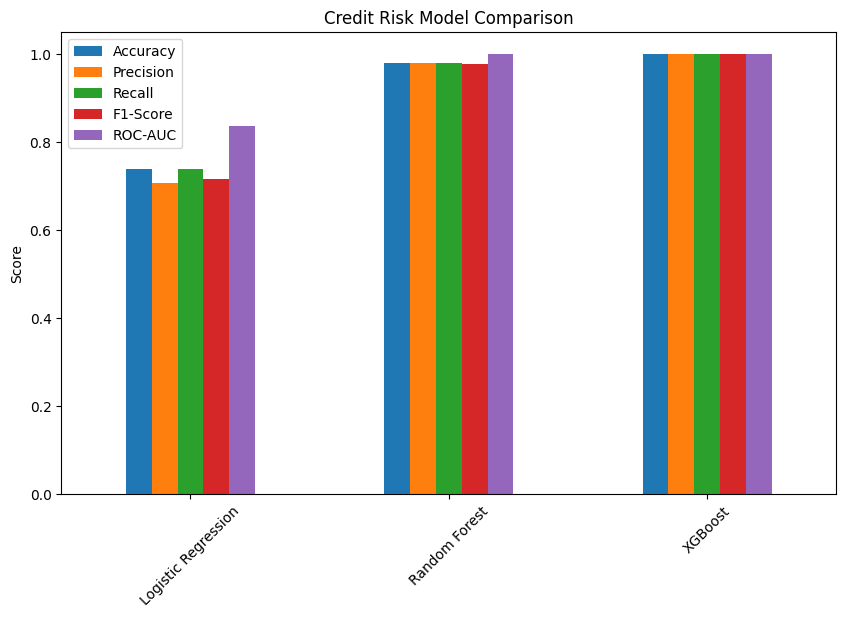

In [ ]:
results_df.T.plot(kind='bar', figsize=(10,6))
plt.title("Credit Risk Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

###12. ROC Curve Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


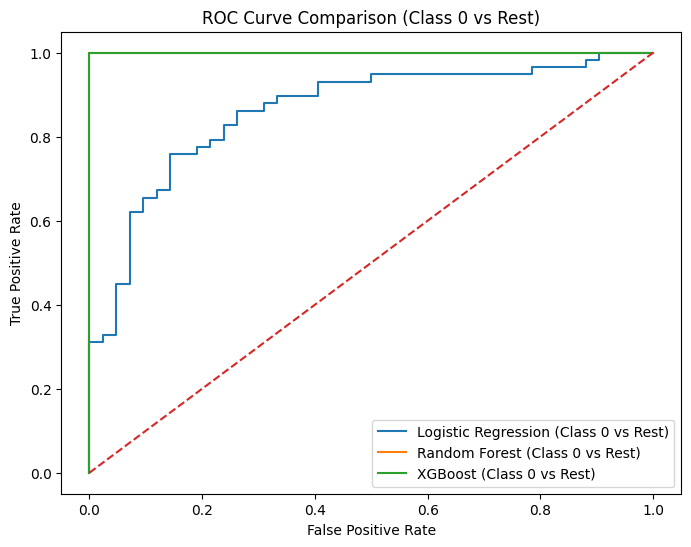

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train) # Refit the model to ensure it's in a fitted state
    if hasattr(model, "predict_proba"):
        y_prob_all_classes = model.predict_proba(X_test)
        y_prob = y_prob_all_classes[:, 0] # Probabilities for class 0 (High Risk)
    else:
        y_prob = model.decision_function(X_test)

    y_test_binary = (y_test == 0).astype(int)

    fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (Class 0 vs Rest)") # Adjust label for clarity

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Class 0 vs Rest)") # Adjust title
plt.legend()
plt.show()